# Ejemplo con generador Gausiano


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import yfinance as yf


# print(plt.style.available) #list of available styles
plt.style.use("ggplot")

warnings.simplefilter(action="ignore", category=FutureWarning)

start_date = '1990-01-01' (9036, 241)

start_date = '1900-01-01' (16077, 23)



In [2]:
start_date = '1945-01-01'

filepath = 'https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python-2023/main/Tema_5_APT/data/sp500_tickers.csv'
tickers_sp500 = list(pd.read_csv(filepath))

precios_close = yf.download(tickers_sp500, start=start_date, auto_adjust=True, progress=True)['Close']

precios_close.dropna(axis=1, inplace=True)

[*******               14%                       ]  69 of 503 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: JNPR"}}}
[*******               14%                       ]  70 of 503 completed$JNPR: possibly delisted; no timezone found
[*******               14%                       ]  72 of 503 completed$BRK.B: possibly delisted; no timezone found
[*********             18%                       ]  89 of 503 completed$DFS: possibly delisted; no timezone found
[************          24%                       ]  123 of 503 completed$FI: possibly delisted; no timezone found
[*************         28%                       ]  141 of 503 completed$PARA: possibly delisted; no timezone found
[*****************     36%                       ]  179 of 503 completed$IPG: possibly delisted; no timezone found
[*****************     36%                       ]  180 of 503 completed$HOLX: possibly delisted; no timezone fo

In [3]:
precios_close.dropna(axis=1, inplace=True)

In [4]:
returns = np.log(precios_close).diff().dropna()
returns.shape

(16244, 23)

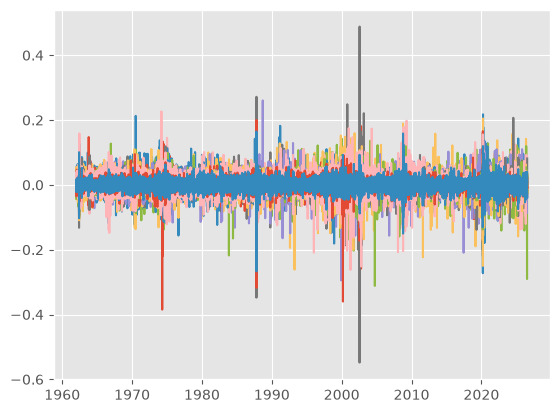

In [5]:
plt.plot(returns)

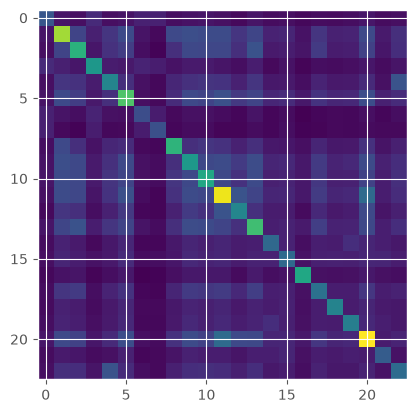

In [6]:
plt.imshow(np.cov(returns.T))

## Definir Parámetros de Ventana

### Subtask:
Establecer las longitudes de las ventanas para X (60 días) y para Y (N días, con un valor predeterminado de 30 días, que el usuario podrá modificar fácilmente).


**Reasoning**:
Define the window sizes for X and Y datasets as specified in the instructions. `window_size_Y` is made easily modifiable.



In [34]:
window_size_X = 60
window_size_Y = 30

print(f"Window size for X: {window_size_X} days")
print(f"Window size for Y (default): {window_size_Y} days")

Window size for X: 60 days
Window size for Y (default): 30 days


**Reasoning**:
Generate the `X` and `Y` datasets by iterating through the `returns` DataFrame, creating 60-day historical return windows for `X` and averaging the subsequent `window_size_Y` days for `Y`, then converting them to NumPy arrays.



In [35]:
X_data = []
Y_data = []

# Ensure there is enough data for both X and Y windows
# The loop goes up to len(returns) - window_size_Y to ensure a full Y window can be extracted
for i in range(window_size_X, len(returns) - window_size_Y):
    # X window: 60 days of historical returns
    X_window = returns.iloc[i - window_size_X:i].values
    X_data.append(X_window)

    # Y window: average of the subsequent N days of returns
    Y_window = returns.iloc[i:i + window_size_Y].values
    # Calculate the average of returns for the Y window
    Y_avg = np.mean(Y_window, axis=0) # average each column (ticker) over the window
    Y_data.append(Y_avg)

X = np.array(X_data)
Y = np.array(Y_data)

print(f"Shape of X dataset: {X.shape}")
print(f"Shape of Y dataset: {Y.shape}")

Shape of X dataset: (16154, 60, 23)
Shape of Y dataset: (16154, 23)


In [36]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train_aux, X_test, Y_train_aux, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

X_train, X_val, Y_train, Y_val = train_test_split(X_train_aux, Y_train_aux, test_size=0.1, random_state=42)


# Datos syntheticos Gausianos

In [37]:
XY_aux = np.zeros((X_train_aux.shape[0],X_train_aux.shape[1]+1,X_train_aux.shape[2]))
XY_aux[:,0:X_train_aux.shape[1],:] = X_train_aux
XY_aux[:,X_train_aux.shape[1],:] = Y_train_aux


In [38]:
XY_aux_flat = XY_aux.reshape(XY_aux.shape[0],XY_aux.shape[1]*XY_aux.shape[2])

XY_aux_flat.shape

(14538, 1403)

In [39]:
# Estadísticas gausianas

mean_XY = np.mean(XY_aux_flat,axis=0)
cov_XY = np.cov(XY_aux_flat.T)

print(mean_XY.shape)
print(cov_XY.shape)


(1403,)
(1403, 1403)


In [47]:
# Inicializamos el generador de números aleatorios
rng = np.random.default_rng(seed=42)

# Generamos las muestras
n_muestras = 10000
XY_synth_flat = rng.multivariate_normal(mean_XY, cov_XY, size=n_muestras)

In [48]:
print(XY_synth_flat.shape)

(10000, 1403)


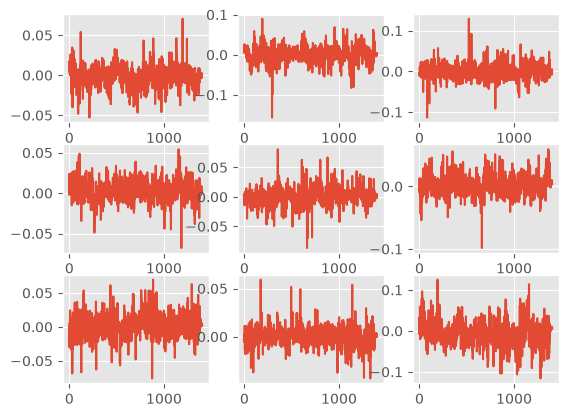

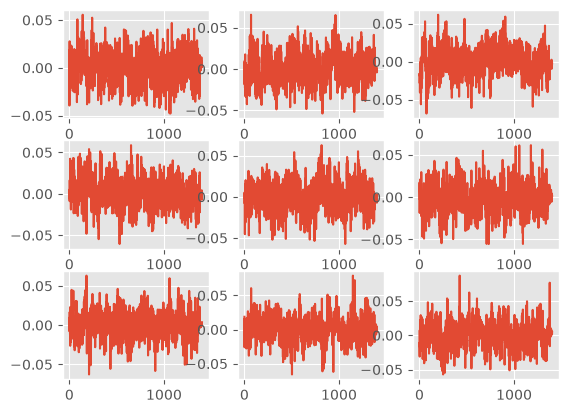

In [49]:
import matplotlib.pyplot as plt

plt.figure()
for n in range(9):
    plt.subplot(3,3,n+1)
    plt.plot(XY_aux_flat[n*10,:].T)


plt.figure()
for n in range(9):
    plt.subplot(3,3,n+1)
    plt.plot(XY_synth_flat[n*10,:].T)

In [50]:
# Reordenamos

XY_synth = np.reshape(XY_synth_flat,[XY_synth_flat.shape[0],XY_aux.shape[1],XY_aux.shape[2]])

XY_synth.shape

(10000, 61, 23)

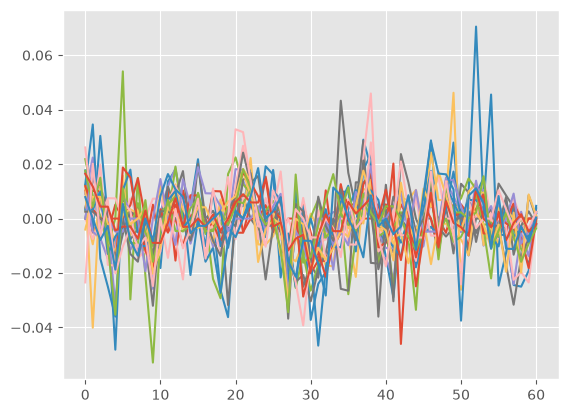

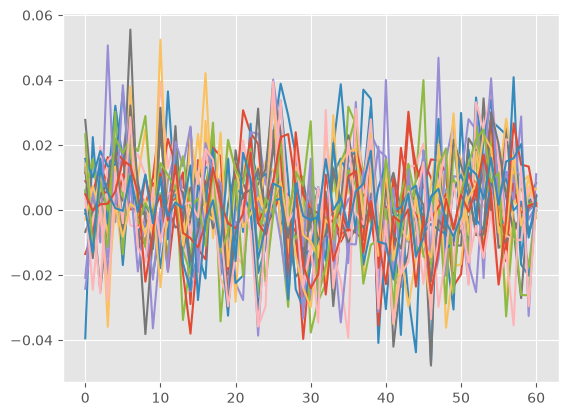

In [51]:

plt.figure()
plt.plot(XY_aux[0])


plt.figure()
plt.plot(XY_synth[0])

In [52]:
# Separamos X e Y 

X_train_aux_synth = XY_synth[:,0:X_train_aux.shape[1],:]
Y_train_aux_synth = XY_synth[:,X_train_aux.shape[1],:]

print(X_train_aux_synth.shape)
print(Y_train_aux_synth.shape)

(10000, 60, 23)
(10000, 23)


In [55]:
X_train_ext = np.concatenate((X_train, X_train_aux_synth), axis=0)
Y_train_ext = np.concatenate((Y_train, Y_train_aux_synth), axis=0)

# Entrenamiento con Sintéticos

In [56]:

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Assuming X, Y, X_train, X_test, Y_train, Y_test, loss, mae, baseline_mse, baseline_mae, lr_mse, lr_mae are already defined from previous steps

# Define the CNN model
# X_train shape is (samples, timesteps, features) -> (None, 60, 23)
cnn_model_2 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(Y_train.shape[1]) # Output layer with no activation for regression
])

# Compile the CNN model
cnn_model_2.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the CNN model summary
print("\n--- CNN Model Summary ---")
cnn_model_2.summary()




--- CNN Model Summary ---


/Users/valero/Documents/CLASES/CURSOS_AI/CURSOS/TAREAS/MIAX14/Taler_B5_T1/SOLUCIONES/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,887 (565.96 KB)

 Trainable params: 144,887 (565.96 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Train the CNN model
print("\nTraining the CNN model...")
history_cnn_2 = cnn_model_2.fit(X_train_ext, Y_train_ext, epochs=300, batch_size=32, validation_data=(X_val,Y_val), verbose=1)




Training the CNN model...
Epoch 1/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 9.2511e-06 - mae: 0.0023 - val_loss: 8.9687e-06 - val_mae: 0.0022
Epoch 2/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.1035e-06 - mae: 0.0023 - val_loss: 9.0012e-06 - val_mae: 0.0022
Epoch 3/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.0897e-06 - mae: 0.0023 - val_loss: 9.1762e-06 - val_mae: 0.0023
Epoch 4/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.0731e-06 - mae: 0.0023 - val_loss: 9.1168e-06 - val_mae: 0.0022
Epoch 5/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.0939e-06 - mae: 0.0023 - val_loss: 9.0675e-06 - val_mae: 0.0022
Epoch 6/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.0729e-06 - mae: 0.0023 - val_loss: 9.4429e-06 - val_mae: 0.0023
Epoch 7/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.0767e-06 - mae: 0.0023 - val_loss: 9.0552e-06 - val_mae: 0.0022
Epoch 8/300
722/722 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.0688e-06 - mae: 0.002

Text(0.5, 0, 'epoch')

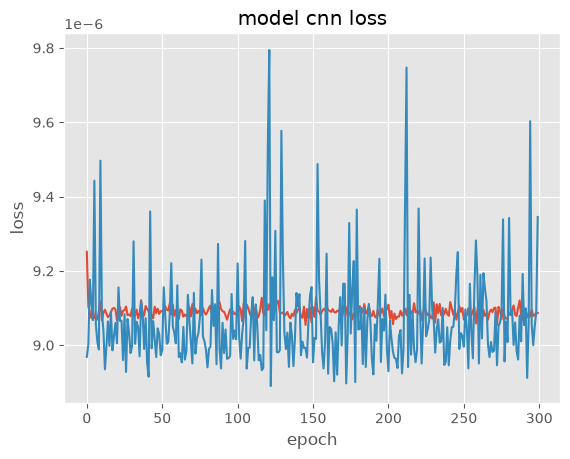

In [58]:
plt.plot(history_cnn_2.history['loss'])
plt.plot(history_cnn_2.history['val_loss'])
plt.title('model cnn loss')
plt.ylabel('loss')
plt.xlabel('epoch')

In [59]:
# Evaluate the CNN model on the test data

cnn_2_loss, cnn_2_mae = cnn_model_2.evaluate(X_test, Y_test, verbose=0)

print(f"CNN 2 Test Loss (MSE): {cnn_2_loss:.4f}")
print(f"CNN 2 Test Mean Absolute Error (MAE): {cnn_2_mae:.4f}")

CNN 2 Test Loss (MSE): 0.0000
CNN 2 Test Mean Absolute Error (MAE): 0.0023


# Entrenar modelo sin sinteticos


In [60]:
cnn_model_1 = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(Y_train.shape[1]) # Output layer with no activation for regression
])

# Compile the CNN model
cnn_model_1.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the CNN model summary
print("\n--- CNN Model Summary ---")
cnn_model_1.summary()



--- CNN Model Summary ---


/Users/valero/Documents/CLASES/CURSOS_AI/CURSOS/TAREAS/MIAX14/Taler_B5_T1/SOLUCIONES/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,887 (565.96 KB)

 Trainable params: 144,887 (565.96 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Train the CNN model
print("\nTraining the CNN model...")
history_cnn_1 = cnn_model_1.fit(X_train, Y_train, epochs=300, batch_size=32, validation_data=(X_val,Y_val), verbose=1)




Training the CNN model...
Epoch 1/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 9.5401e-06 - mae: 0.0022 - val_loss: 8.9285e-06 - val_mae: 0.0022
Epoch 2/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 9.0313e-06 - mae: 0.0022 - val_loss: 8.8898e-06 - val_mae: 0.0022
Epoch 3/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.8416e-06 - mae: 0.0022 - val_loss: 8.5596e-06 - val_mae: 0.0022
Epoch 4/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.4248e-06 - mae: 0.0021 - val_loss: 8.1622e-06 - val_mae: 0.0021
Epoch 5/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.7590e-06 - mae: 0.0021 - val_loss: 7.6394e-06 - val_mae: 0.0021
Epoch 6/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.2445e-06 - mae: 0.0020 - val_loss: 7.3884e-06 - val_mae: 0.0020
Epoch 7/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.7855e-06 - mae: 0.0019 - val_loss: 6.7878e-06 - val_mae: 0.0019
Epoch 8/300
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.4563e-06 - mae: 0.00

Text(0.5, 0, 'epoch')

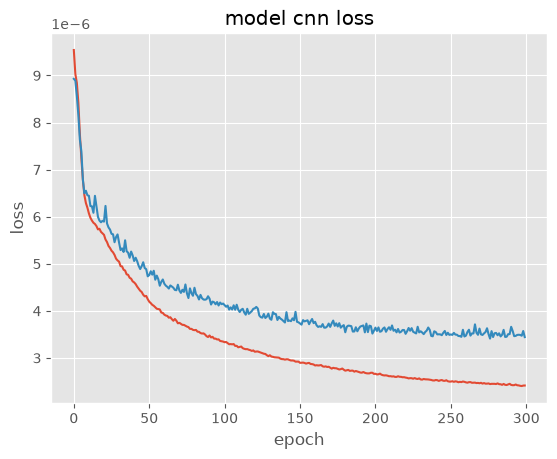

In [62]:
plt.plot(history_cnn_1.history['loss'])
plt.plot(history_cnn_1.history['val_loss'])
plt.title('model cnn loss')
plt.ylabel('loss')
plt.xlabel('epoch')

In [63]:
# Evaluate the CNN model on the test data

cnn_1_loss, cnn_1_mae = cnn_model_1.evaluate(X_test, Y_test, verbose=0)

print(f"CNN 1 Test Loss (MSE): {cnn_1_loss:.4f}")
print(f"CNN 1 Test Mean Absolute Error (MAE): {cnn_1_mae:.4f}")

print(f"CNN 2 Test Loss (MSE): {cnn_2_loss:.4f}")
print(f"CNN 2 Test Mean Absolute Error (MAE): {cnn_2_mae:.4f}")

CNN 1 Test Loss (MSE): 0.0000
CNN 1 Test Mean Absolute Error (MAE): 0.0014
CNN 2 Test Loss (MSE): 0.0000
CNN 2 Test Mean Absolute Error (MAE): 0.0023
